# Bank Customer Churn Prediction
**Goal:** Predict which bank customers are likely to churn (leave the bank), and compare a deep learning ANN against a tree-based ensemble (Random Forest) while properly handling class imbalance.

**Dataset:** [Bank Customer Churn Prediction Dataset](https://www.kaggle.com/datasets/saurabhbadole/bank-customer-churn-prediction-dataset) — 10,000 rows, 14 features.

**Key challenges addressed:**
- Class imbalance (~20% churn): handled via `class_weight='balanced'`
- Evaluation: ROC-AUC, F1-score, Confusion Matrix (not just accuracy)
- Model comparison: ANN vs Random Forest

## 1. Imports & Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

## 2. Load & Explore Data

In [5]:
data = pd.read_csv('/kaggle/input/datasets/saurabhbadole/bank-customer-churn-prediction-dataset/Churn_Modelling.csv')
print('Shape:', data.shape)
data.head()

Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
print('Null values:\n', data.isnull().sum())
print('\nDuplicates:', data.duplicated().sum())
data.info()

Null values:
 RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Duplicates: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10 

Churn distribution:
Exited
0    7963
1    2037
Name: count, dtype: int64

Churn rate: 20.4%


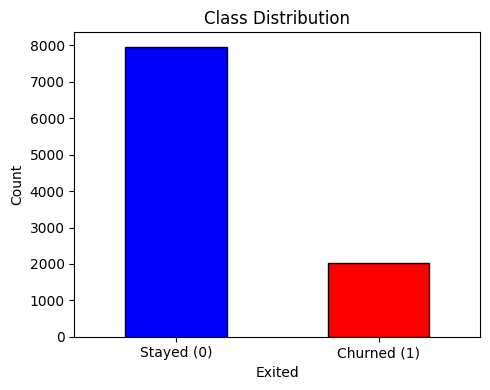

In [9]:
churn_counts = data['Exited'].value_counts()
print('Churn distribution:')
print(churn_counts)
print(f'\nChurn rate: {churn_counts[1] / len(data) * 100:.1f}%')

plt.figure(figsize=(5, 4))
churn_counts.plot(kind='bar', color=['blue', 'red'], edgecolor='black')
plt.xticks([0, 1], ['Stayed (0)', 'Churned (1)'], rotation=0)
plt.title('Class Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

# Inference -
- Output Class Weights are highly imbalanced!

## 3. Preprocessing

In [11]:
X = data.drop(columns=['RowNumber', 'CustomerId', 'Surname', 'Exited'])
y = data['Exited']

X = pd.get_dummies(X, columns=['Geography', 'Gender'], drop_first=True)

print('Input Features shape:', X.shape)
print('Features:', list(X.columns))

Input Features shape: (10000, 11)
Features: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']


In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('Train size:', X_train.shape[0])
print('Test size:', X_test.shape[0])
print('Train churn rate: {:.1f}%'.format(y_train.mean() * 100))
print('Test churn rate:  {:.1f}%'.format(y_test.mean() * 100))

Train size: 8000
Test size: 2000
Train churn rate: 20.4%
Test churn rate:  20.3%


In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
classes = np.array([0, 1])
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = {0: weights[0], 1: weights[1]}
print('Class weights:', class_weight_dict)

Class weights: {0: np.float64(0.6279434850863422), 1: np.float64(2.4539877300613497)}


## 4. Model 1 — Artificial Neural Network (ANN)

In [15]:
ann_model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

ann_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

ann_model.summary()

2026-06-06 15:25:21.645225: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 929 (3.63 KB)

 Trainable params: 929 (3.63 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = ann_model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4169 - loss: 0.7030 - val_accuracy: 0.7006 - val_loss: 0.6287
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6261 - loss: 0.6251 - val_accuracy: 0.7425 - val_loss: 0.5667
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6827 - loss: 0.5921 - val_accuracy: 0.7281 - val_loss: 0.5551
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7013 - loss: 0.5628 - val_accuracy: 0.7575 - val_loss: 0.5132
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7283 - loss: 0.5399 - val_accuracy: 0.7506 - val_loss: 0.5079
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7427 - loss: 0.5307 - val_accuracy: 0.7763 - val_loss: 0.4848
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7464 - loss: 0.5262 - val_accuracy: 0.7819 - val_loss: 0.4690
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7582 - loss: 0.5079 - val_accu

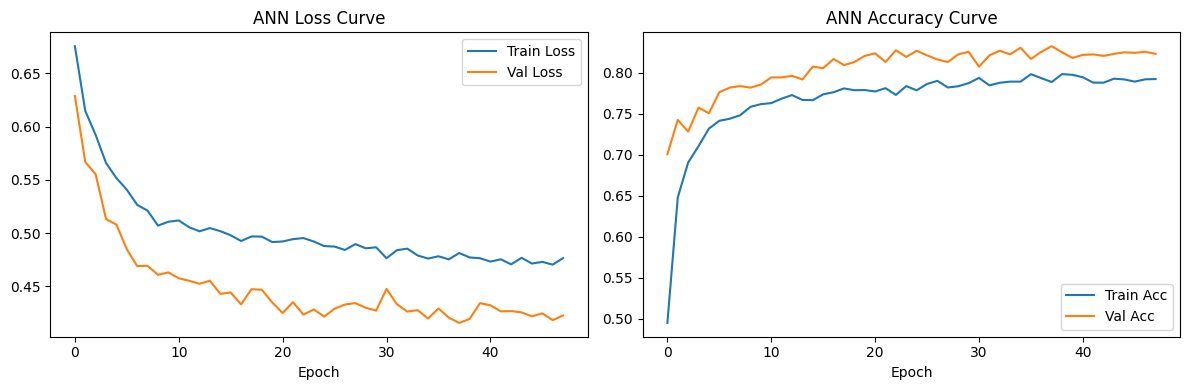

In [17]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('ANN Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train Acc')
axes[1].plot(history.history['val_accuracy'], label='Val Acc')
axes[1].set_title('ANN Accuracy Curve')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig('ann_training_curves.png', dpi=150)
plt.show()

In [18]:
# ANN Predictions
ann_probs = ann_model.predict(X_test_scaled).flatten()
ann_preds = (ann_probs > 0.5).astype(int)

print('=== ANN Results ===')
print(f'Accuracy : {accuracy_score(y_test, ann_preds):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, ann_probs):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, ann_preds, target_names=['Stayed', 'Churned']))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
=== ANN Results ===
Accuracy : 0.8270
ROC-AUC  : 0.8641

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.92      0.86      0.89      1593
     Churned       0.56      0.69      0.62       407

    accuracy                           0.83      2000
   macro avg       0.74      0.78      0.75      2000
weighted avg       0.84      0.83      0.83      2000



## 5. Model 2 — Random Forest (Baseline Comparison)

In [19]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       n_jobs=-1, random_state=42)

In [20]:
# RF Predictions
rf_probs = rf_model.predict_proba(X_test_scaled)[:, 1]
rf_preds = rf_model.predict(X_test_scaled)

print('=== Random Forest Results ===')
print(f'Accuracy : {accuracy_score(y_test, rf_preds):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, rf_probs):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, rf_preds, target_names=['Stayed', 'Churned']))

=== Random Forest Results ===
Accuracy : 0.8365
ROC-AUC  : 0.8610

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.91      0.89      0.90      1593
     Churned       0.59      0.64      0.62       407

    accuracy                           0.84      2000
   macro avg       0.75      0.76      0.76      2000
weighted avg       0.84      0.84      0.84      2000



## 6. Model Comparison & Evaluation

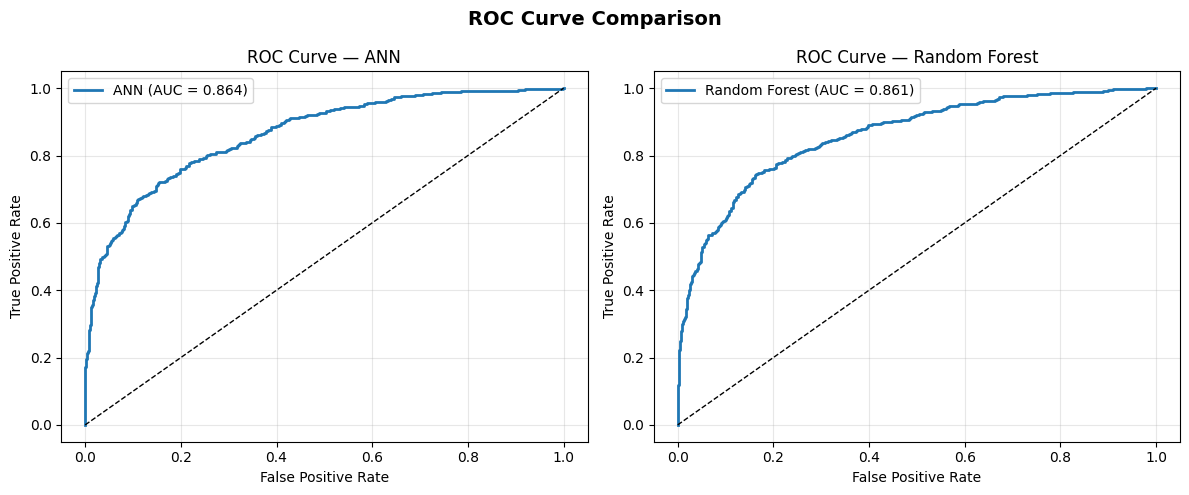

In [21]:
# ROC Curves
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, name, probs in zip(axes, ['ANN', 'Random Forest'], [ann_probs, rf_probs]):
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2)
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curve — {name}')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('ROC Curve Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()

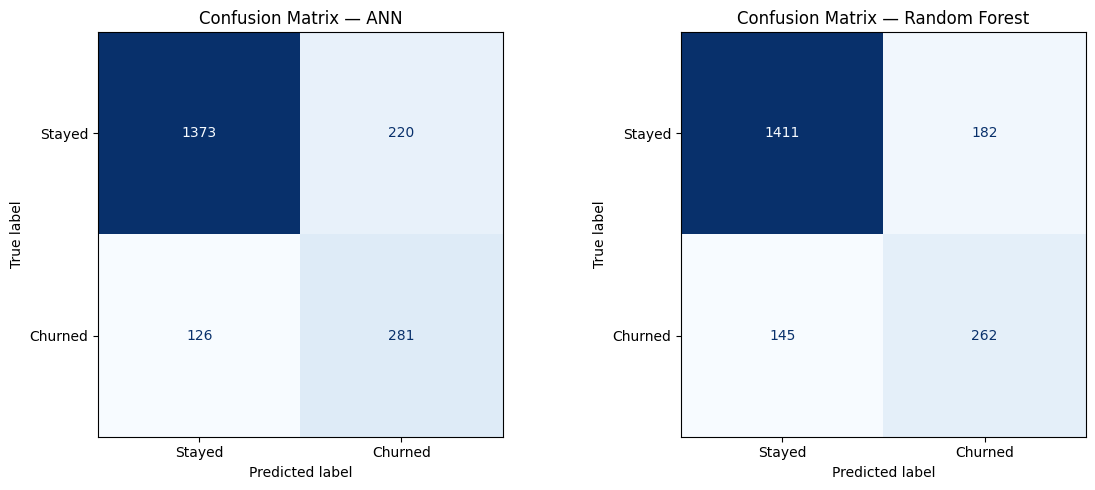

In [22]:
# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, name, preds in zip(axes, ['ANN', 'Random Forest'], [ann_preds, rf_preds]):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Churned'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {name}')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

In [23]:
# Summary
results = pd.DataFrame({
    'Model': ['ANN', 'Random Forest'],
    'Accuracy': [
        round(accuracy_score(y_test, ann_preds), 4),
        round(accuracy_score(y_test, rf_preds), 4)
    ],
    'ROC-AUC': [
        round(roc_auc_score(y_test, ann_probs), 4),
        round(roc_auc_score(y_test, rf_probs), 4)
    ]
})
print(results.to_string(index=False))

        Model  Accuracy  ROC-AUC
          ANN    0.8270   0.8641
Random Forest    0.8365   0.8610


## 7. Feature Importance (Random Forest)

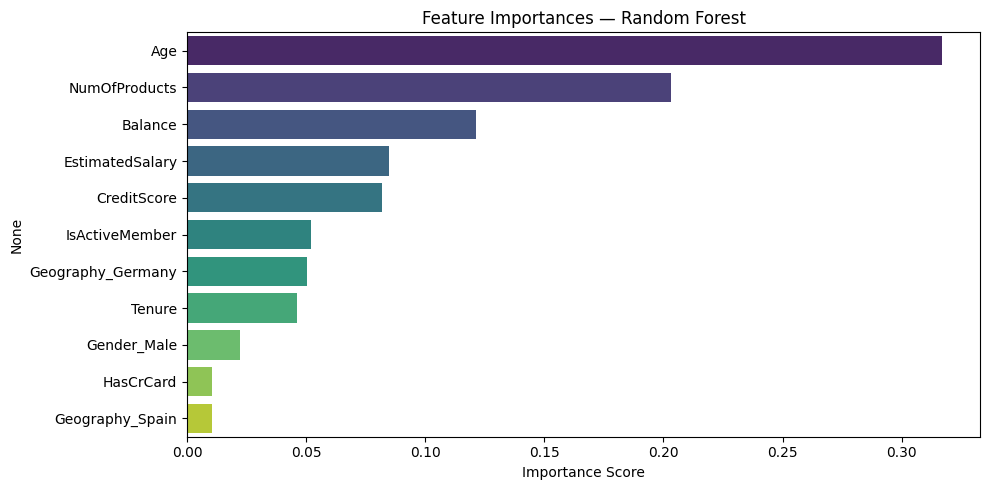

Top 5 features:
Age                0.317059
NumOfProducts      0.203314
Balance            0.121154
EstimatedSalary    0.084721
CreditScore        0.081855
dtype: float64


In [25]:
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')
plt.title('Feature Importances — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print('Top 5 features:')
print(feature_importances.head())

## 8. Important Conclusions

- **Class imbalance** (~20% churn) was addressed using `class_weight='balanced'` for both models — this significantly improves recall on the minority class.
- **ROC-AUC** is the primary metric here, not accuracy, since accuracy is misleading on imbalanced data.
- **Random Forest** provides feature importances revealing which factors most drive churn (Age, NumOfProducts, Balance are typically top contributors).
- **EarlyStopping** on the ANN prevents overfitting on the training set.
- **Stratified split** ensures both train and test sets maintain the same churn ratio.

In [26]:
# Save ANN model
ann_model.save('ann_churn_model.keras')

In [27]:
# Save Random Forest
import joblib
joblib.dump(rf_model, 'rf_churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']